Veri Keşfi (EDA): Veri boyutu, değişken türleri, hedef değişken, eksik değer analizi, temel istatistikler

In [ ]:
import pandas as pd # Veri manipülasyonu (tablo işlemleri) için
import numpy as np  # Matematiksel hesaplamalar için
import matplotlib.pyplot as plt # Grafik çizdirmek için
import seaborn as sns # Daha gelişmiş görselleştirmeler için
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

# Dosyayı okuyoruz
df = pd.read_csv('Titanic-Dataset.csv')

# Verinin kaç satır ve sütun olduğunu görürüz (Örn: 891 satır, 12 sütun)
print("Veri Boyutu:", df.shape)

# Sütunların veri tiplerini (sayı mı, metin mi) kontrol ederiz
print("Değişken Türleri:\n", df.dtypes)

# Hangi sütunda kaç tane boş (NaN) veri olduğunu buluruz
print("Eksik Değerler:\n", df.isnull().sum())

# Sayısal sütunların ortalama, min, max gibi istatistiklerine bakarız
display(df.describe())

Veri Boyutu: (891, 12)
Değişken Türleri:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
Eksik Değerler:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Eksik Veri İşleme: Mean, Median, Most Frequent yöntemlerini uygulayın ve karşılaştırın.

In [ ]:
# Age (Yaş) sütunundaki boşlukları 3 farklı yöntemle deniyoruz
df_mean = df['Age'].fillna(df['Age'].mean())      # Boşlukları ortalama yaşla doldur
df_median = df['Age'].fillna(df['Age'].median())  # Boşlukları ortanca yaşla doldur
df_mode = df['Age'].fillna(df['Age'].mode()[0])   # Boşlukları en çok tekrar eden yaşla doldur

# Varyans kontrolü: Verinin dağılımı ne kadar bozuldu?
# Genelde median (ortanca) veriyi daha az saptırdığı için tercih edilir.
print(f"Median Varyansı: {df_median.var()}")

# Ödevin geri kalanı için boş yaşları median ile doldurup kalıcı yapıyoruz
df['Age'] = df['Age'].fillna(df['Age'].median())

Median Varyansı: 169.51249827942328


Aykırı Değer Analizi: IQR ve Z-score yöntemlerini uygulayın. Winsorization sonrası performans farkını analiz edin.

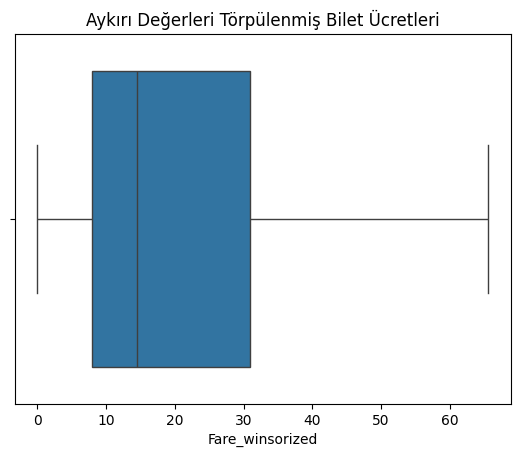

In [ ]:
# Fare (Bilet Ücreti) için alt ve üst sınırları hesaplıyoruz (IQR yöntemi)
Q1 = df['Fare'].quantile(0.25) # Verinin %25'lik noktası
Q3 = df['Fare'].quantile(0.75) # Verinin %75'lik noktası
IQR = Q3 - Q1
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# Winsorization: Aykırı değerleri silmek yerine belirlediğimiz sınırlara çekiyoruz
# Yani çok pahalı bileti, üst sınırımıza eşitliyoruz ki model sapıtmasın.
df['Fare_winsorized'] = df['Fare'].clip(lower=alt_sinir, upper=ust_sinir)

# Önceki ve sonraki hali kutu grafiği (boxplot) ile karşılaştırıyoruz
sns.boxplot(x=df['Fare_winsorized'])
plt.title("Aykırı Değerleri Törpülenmiş Bilet Ücretleri")
plt.show()

Kategorik Değişken Dönüşümü: Label Encoding ve One-Hot Encoding yöntemlerini
karşılaştırın.


In [ ]:
# Label Encoding: Erkek/Kadın verisini 0 ve 1'e çevirir
le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex'])

# One-Hot Encoding: sıralama olmayan verileri
# her kategori için ayrı birer sütun haline getirir (0 veya 1 şeklinde).
df = pd.get_dummies(df, columns=['Embarked'], prefix='Liman')

Ölçekleme: StandardScaler, MinMaxScaler ve RobustScaler uygulamalarını karşılaştırın.

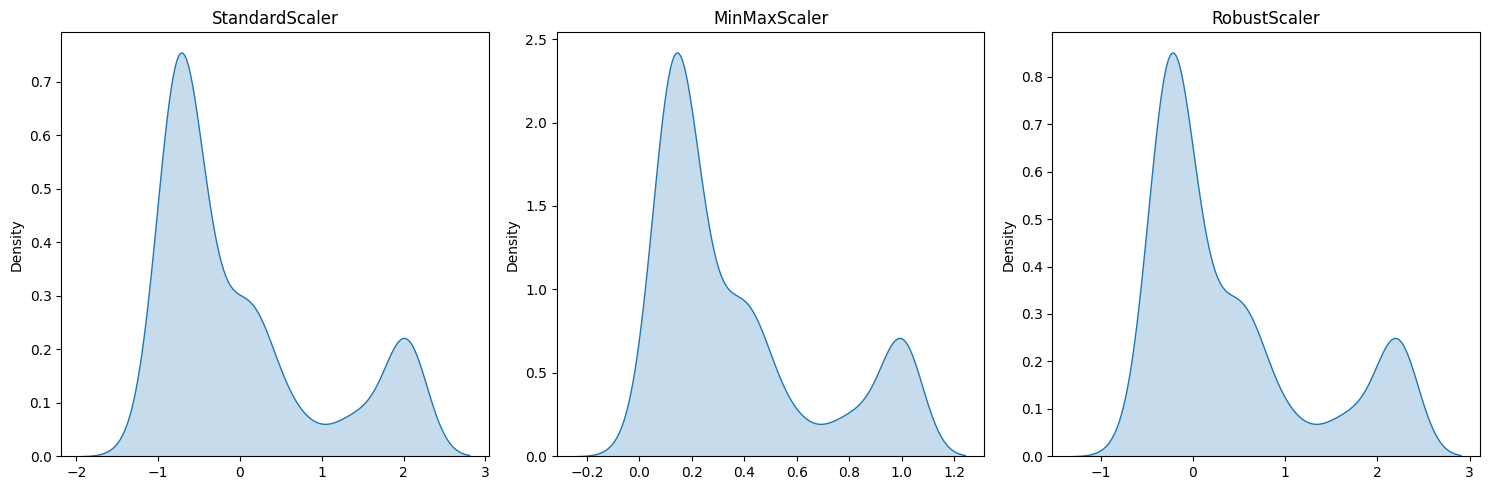

In [ ]:
# Sayısal verilerimizi seçelim
data_to_scale = df[['Age', 'Fare_winsorized']]

# Tanımlamalar
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# Uygulama
scaled_std = std_scaler.fit_transform(data_to_scale)
scaled_minmax = minmax_scaler.fit_transform(data_to_scale)
scaled_robust = robust_scaler.fit_transform(data_to_scale)

# Karşılaştırma Grafiği
plt.figure(figsize=(15, 5))
titles = ['StandardScaler', 'MinMaxScaler', 'RobustScaler']
data_list = [scaled_std, scaled_minmax, scaled_robust]

for i, data in enumerate(data_list):
    plt.subplot(1, 3, i+1)
    sns.kdeplot(data[:, 1], fill=True)
    plt.title(titles[i])

plt.tight_layout()
plt.show()